# 🩺 피마 인디언 당뇨병 데이터 분석 기초

이 노트북은 데이터 분석 입문자를 위한 **데이터 품질 검증(결측치, 중복값, 이상치)** 실습 가이드입니다.

### 📌 학습 목표
1. 판다스(Pandas)를 이용한 데이터 로드 및 구조 파악
2. 데이터 중복 여부 확인
3. 단순 NaN 결측치뿐만 아니라 **도메인 특성상 0으로 표기된 숨은 결측치** 파악
4. **사분위수 범위(IQR)**를 활용한 이상치 탐지 및 박스플롯(Boxplot) 시각화

## 1. 라이브러리 임포트 및 시각화 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Mac 환경: AppleGothic, Windows: Malgun Gothic)
plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic")

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


## 2. 데이터 불러오기
원본 데이터는 컬럼 헤더가 없으므로 직접 컬럼명을 지정해 줍니다.

In [2]:
columns = [
    "Pregnancies",               # 임신 횟수
    "Glucose",                   # 포도당 수치
    "BloodPressure",             # 혈압
    "SkinThickness",             # 삼두근 피부 두께
    "Insulin",                   # 혈청 인슐린
    "BMI",                       # 체질량 지수
    "DiabetesPedigreeFunction",  # 당뇨 유전 가중치
    "Age",                       # 나이
    "Outcome"                    # 당뇨 여부 (0: 정상, 1: 당뇨)
]

df = pd.read_csv("pima-indians-diabetes.csv", names=columns)
print(f"데이터 크기: {df.shape[0]}행 {df.shape[1]}열")
df.head()

데이터 크기: 768행 9열


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 📊 데이터 요약 통계 확인
`df.describe()`를 통해 평균, 표준편차, 최솟값(min), 최댓값(max)을 한눈에 볼 수 있습니다.
여기서 `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`의 `min` 값이 **0**인 것에 주목하세요!

In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. 중복값(Duplicates) 검증
동일한 데이터가 중복 수집되었는지 확인합니다.

In [4]:
dup_count = df.duplicated().sum()
print(f"중복된 행의 수: {dup_count}개")
if dup_count == 0:
    print("🎉 중복 데이터가 없습니다!")
else:
    print(f"⚠️ 중복 행 {dup_count}개 발견. df.drop_duplicates() 필요.")

중복된 행의 수: 0개
🎉 중복 데이터가 없습니다!


## 4. 결측치(Missing Values) 검증

### 1) 단순 NaN 결측치 확인
판다스의 `isnull().sum()`으로 확인해 봅니다.

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### 2) 도메인 상식 기반: 0으로 입력된 "숨은 결측치" 찾기
사람의 혈압이나 포도당 수치, 인슐린, BMI가 0일 수는 없습니다.
이 값들은 실제로 **측정되지 않아 0으로 기록된 결측치**입니다.

In [6]:
zero_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_summary = []
for col in zero_features:
    cnt = (df[col] == 0).sum()
    pct = (cnt / len(df)) * 100
    zero_summary.append({"컬럼": col, "0값 개수": cnt, "비율(%)": round(pct, 2)})

zero_df = pd.DataFrame(zero_summary)
zero_df

,컬럼,0값 개수,비율(%)
0,Glucose,5,0.65
1,BloodPressure,35,4.56
2,SkinThickness,227,29.56
3,Insulin,374,48.70
4,BMI,11,1.43


### 3) 결측치 시각화 (바차트 & 히트맵)

/var/folders/bf/qpyv75sx5bd3kd5fyh_btfn80000gn/T/ipykernel_35800/3227128087.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zero_df, x="컬럼", y="비율(%)", palette="Reds_r", ax=axes[0])


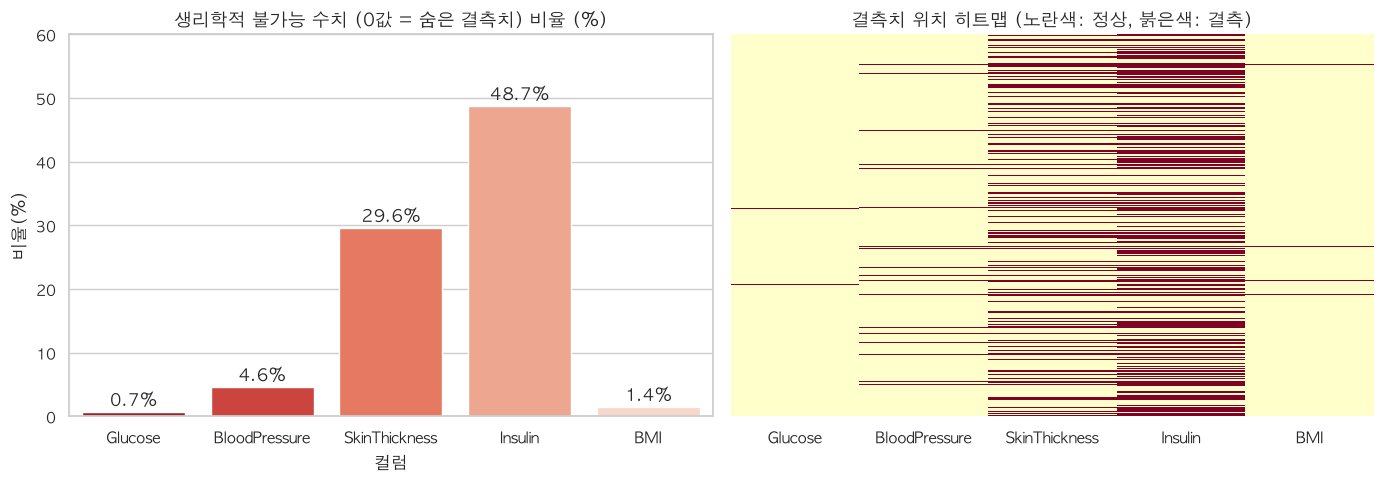

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 0값 비율 바차트
sns.barplot(data=zero_df, x="컬럼", y="비율(%)", palette="Reds_r", ax=axes[0])
axes[0].set_title("생리학적 불가능 수치 (0값 = 숨은 결측치) 비율 (%)", fontsize=13)
axes[0].set_ylim(0, 60)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha="center")

# (2) 결측치 분포 히트맵
df_nan = df.copy()
df_nan[zero_features] = df_nan[zero_features].replace(0, np.nan)
sns.heatmap(df_nan[zero_features].isnull(), cbar=False, cmap="YlOrRd", ax=axes[1], yticklabels=False)
axes[1].set_title("결측치 위치 히트맵 (노란색: 정상, 붉은색: 결측)", fontsize=13)

plt.tight_layout()
plt.show()

## 5. 이상치(Outliers) 검증

**IQR(Interquartile Range) 방식**을 사용하여 데이터의 사분위수를 구하고 정상 범위를 벗어난 이상치를 탐색합니다.

In [8]:
feature_cols = columns[:-1] # Outcome 제외한 특성들
outlier_list = []

for col in feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    outlier_list.append({
        "컬럼": col,
        "이상치 개수": len(outliers),
        "정상 하한값": round(lower_limit, 2),
        "정상 상한값": round(upper_limit, 2)
    })

pd.DataFrame(outlier_list)

,컬럼,이상치 개수,정상 하한값,정상 상한값
0,Pregnancies,4,-6.50,13.50
1,Glucose,5,37.12,202.12
2,BloodPressure,45,35.00,107.00
3,SkinThickness,1,-48.00,80.00
4,Insulin,34,-190.88,318.12
5,BMI,19,13.35,50.55
6,DiabetesPedigreeFunction,29,-0.33,1.20
7,Age,9,-1.50,66.50


### 📊 이상치 박스플롯(Boxplot) 시각화
수염(Whisker) 바깥에 위치한 붉은 점들이 IQR 기준 이상치입니다.

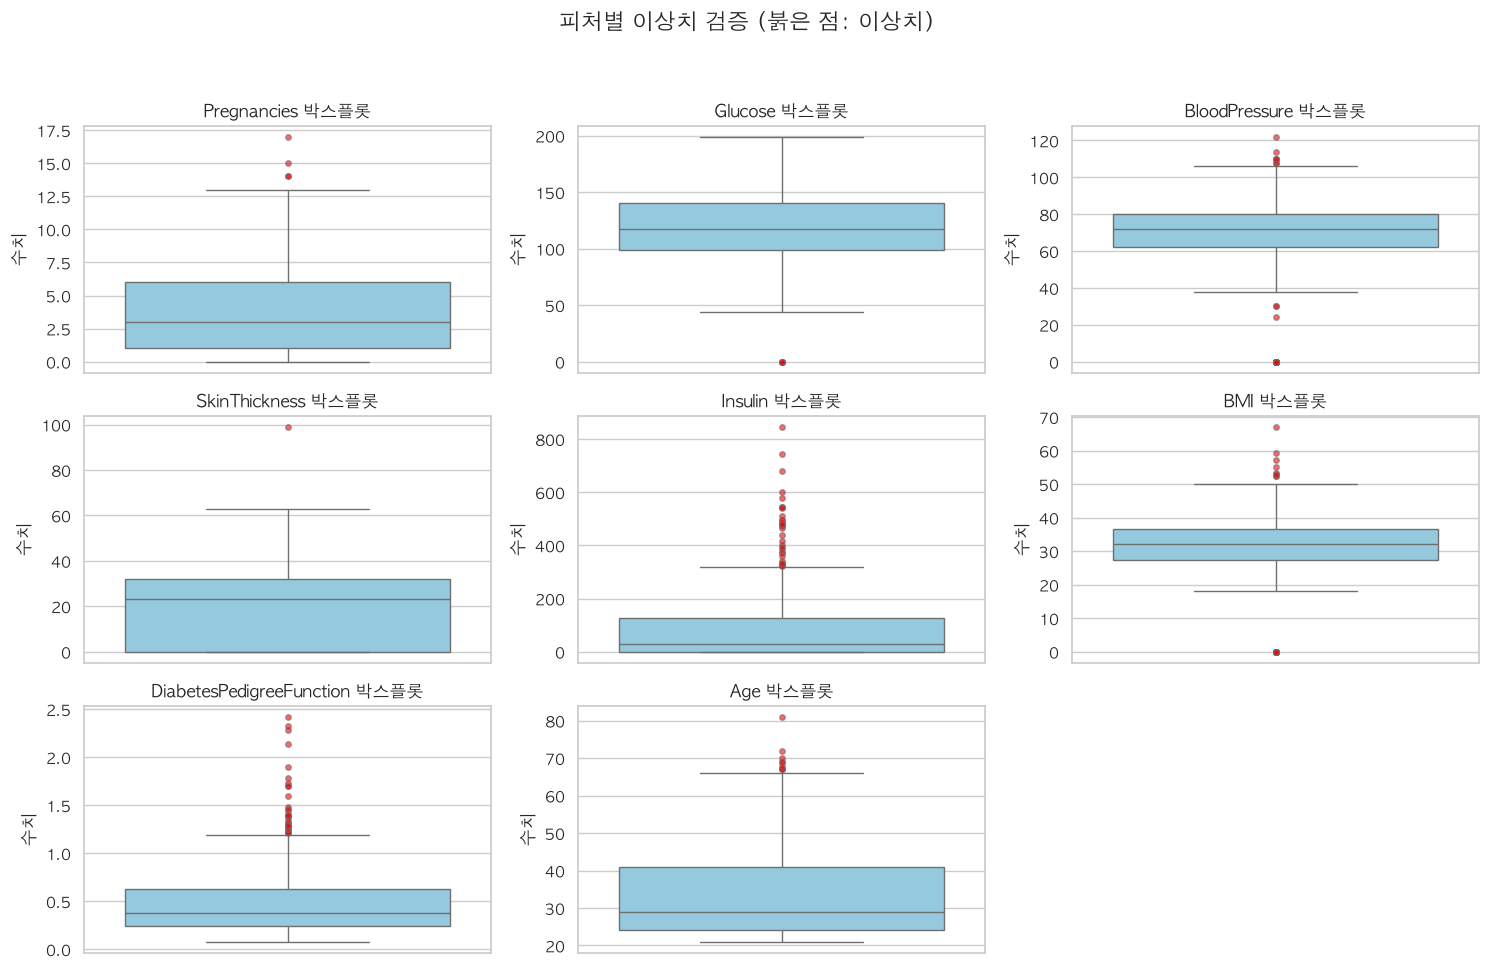

In [9]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color="skyblue", flierprops=dict(marker="o", markersize=4, markerfacecolor="red", alpha=0.6))
    plt.title(f"{col} 박스플롯", fontsize=12)
    plt.ylabel("수치")

plt.suptitle("피처별 이상치 검증 (붉은 점: 이상치)", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

## 🎯 검증 결론 및 다음 학습 추천
1. **중복값**: 0개 (추가 조치 불필요)
2. **결측치**: `Insulin`(48.7%), `SkinThickness`(29.6%)에 심각한 0값 결측치 존재 -> 다음 단계에서 **중앙값(Median) 대체** 또는 결측치 처리 필요
3. **이상치**: 인슐린, 혈압, BMI 등에서 극단값 발견 -> 분석 목적에 따라 스케일링(RobustScaler 등) 또는 로그 변환 적용 고려